# Cv

From the growth rate and the condensation sink it is possible to derive estimates for the condensing vapor concentration Cv and its source
rate Q following the analysis by Kulmala et al. (2001a) and Dal Maso et al. (2002), which is summarized in the following. Assuming that the
particle growth is caused by condensation of a low vapor pressure vapor to the particle surface we can integrate the mass flux equation to derive
Cv according to (Kulmala 1988). 

In the nucleation size range this leads to a simple approximate relation between the growth rate and the vapor concentration:

the condensing vapor concentration Cv

Cv = A X dDp/dt.

Here A is a constant, which has the value 1.37 x 107 h cm–3 nm–1 for a vapor with molecular properties of sulfuric acid. Thus, a growth rate of 1 nm h–1 corresponds to a vapor concentration of 1.37 x 107 cm–3

Q is the vapor source rate.

Q = CS x Cv = CS x A x dDp/dt. (103 cm–3 s–1)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import date, timedelta

plt.rcParams["font.family"] = 'monospace'
current_dir = r'C:\Users\DominicHeslinRees\AR_2025'

In [3]:
method_name = 'rate'
path=r'C:\Users\Dell\Documents\NAIS_work\select_bonds\NPF_events_DMPS_NAIS\GR_dfs'
path=r'C:\Users\Dell\Documents\AR_2025\Analysis\event_days_nc\GR_dfs'
df_NPF_for_hsplit = pd.read_csv(path+'\\'+'GR_'+str(method_name)+'.dat',
    index_col=0,parse_dates=True)

In [5]:
df_NPF_for_hsplit.head(2)

,diameters,time_delta,time_delta_hourly,slope,starttime,endtime,date
2024-10-01 23:00:00,7.763048e-09,6.370491,6.0,1.218595e-09,2024-10-01,2024-10-01 23:15:00,2024-10-01
2024-10-01 22:00:00,6.544453e-09,5.370491,5.0,1.218595e-09,2024-10-01,2024-10-01 23:15:00,2024-10-01


In [6]:
do_not_include = ['2022-06-25', '2022-08-15', '2023-05-26', '2023-06-06', '2023-07-07', '2023-09-19', '2024-05-04', '2024-05-15', 
'2024-05-20', '2024-06-06', '2024-06-30', '2024-07-08', '2024-07-16', 
'2024-07-19', '2024-07-22','2024-09-13']

In [7]:
do_not_include = ['2023-06-06','2024-05-20', '2024-07-08', '2024-07-16', '2024-09-13']

In [8]:
print(len(df_NPF_for_hsplit))
df_NPF_for_hsplit = df_NPF_for_hsplit[~df_NPF_for_hsplit['date'].isin(do_not_include)]
print(len(df_NPF_for_hsplit))
df_slope = df_NPF_for_hsplit[['slope']].copy()
df_slope_hr = df_slope.resample('H').mean()
df_slope_hr = df_slope_hr*10**9
df_slope_hr.slope.mean()

772
758


C:\Users\Dell\AppData\Local\Temp\ipykernel_15908\185382403.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_slope_hr = df_slope.resample('H').mean()


np.float64(2.007177633313044)

In [9]:
df_slope_hr.head(2)

,slope
2022-04-18 11:00:00,1.739578
2022-04-18 12:00:00,1.739578


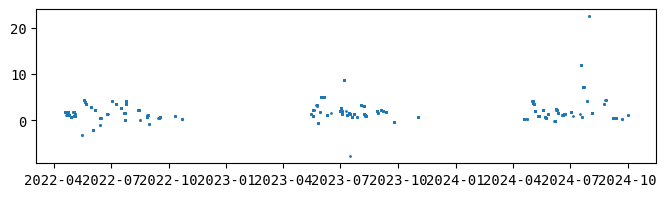

In [10]:
fig, ax = plt.subplots(figsize=(8,2))
ax.plot(df_slope_hr.index, df_slope_hr.slope, 'o', ms=1)
plt.show()

In [11]:
float(df_slope_hr.max())

C:\Users\Dell\AppData\Local\Temp\ipykernel_15908\1637281639.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(df_slope_hr.max())


22.557098716864516

In [12]:
df_slope_hr.min()

slope   -7.759909
dtype: float64

In [13]:
df_slope_hr[df_slope_hr['slope'] == float(df_slope_hr.max())]

C:\Users\Dell\AppData\Local\Temp\ipykernel_15908\2865679611.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_slope_hr[df_slope_hr['slope'] == float(df_slope_hr.max())]


,slope
2024-07-31 13:00:00,22.557099
2024-07-31 14:00:00,22.557099


In [14]:
df_slope_hr[df_slope_hr['slope'] == float(df_slope_hr.min())]

C:\Users\Dell\AppData\Local\Temp\ipykernel_15908\1575917387.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_slope_hr[df_slope_hr['slope'] == float(df_slope_hr.min())]


,slope
2023-07-17 14:00:00,-7.759909


In [15]:
df_CS_hourly = pd.read_csv(current_dir+'\\Analysis\\CS\\CS_hourly.dat', index_col=0, parse_dates=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DominicHeslinRees\\AR_2025\\Analysis\\CS\\CS_hourly.dat'

In [ ]:
A = 1.37*10**7 #h cm–3 nm–1
df_Cv = df_slope_hr*A
df_Cv = df_Cv.rename(columns={'slope':'Cv'})

df_Cv.index = pd.to_datetime(df_Cv.index)
df_Cv['month'] = df_Cv.index.month

def q75(x):
    return x.quantile(0.75)
def q50(x):
    return x.quantile(0.5)
def q25(x):
    return x.quantile(0.25)

In [ ]:
df_Cv

,Cv,month
datetimes,,
2022-04-18 09:00:00,2.383222e+07,4
2022-04-18 10:00:00,2.383222e+07,4
2022-04-18 11:00:00,2.383222e+07,4
2022-04-18 12:00:00,2.383222e+07,4
2022-04-18 13:00:00,2.383222e+07,4
...,...,...
2024-10-02 00:00:00,8.658487e+06,10
2024-10-02 01:00:00,8.658487e+06,10
2024-10-02 02:00:00,8.658487e+06,10


In [ ]:
def monthly_averages(df, var):
    df_M = df.resample('M').median()
    df_M = df.groupby('month').median()
    df_M = df.groupby('month').mean()
    df_M = df.groupby('month').agg({var: [q50, q25, q75, 'mean']})
    df_M.columns = ['q50', 'q25', 'q75', 'mean']
    return df_M

In [ ]:
df_Cv_M = monthly_averages(df_Cv, var='Cv')

In [ ]:
df_Cv_M.head(2)

,q50,q25,q75,mean
month,,,,
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN


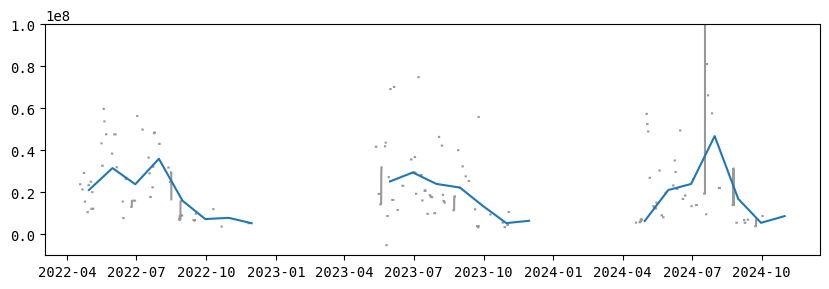

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_Cv.index, df_Cv['Cv'].values, c='k', alpha=.4)
df_Cv_resample = df_Cv.resample('M').mean()
ax.plot(df_Cv_resample.index, df_Cv_resample['Cv'].values)
ax.set_ylim(-.1*10**8, 1*10**8 )
plt.show()

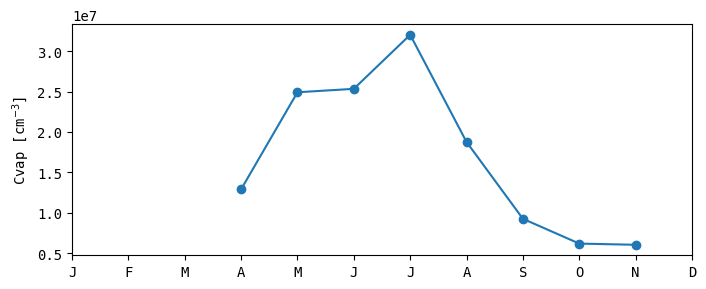

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df_Cv_M.index, df_Cv_M['mean'].values, 'o-')
ax.set_ylabel('Cvap [cm$^{-3}$]')
ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
plt.show()

In [ ]:
df_Cv_M

,q50,q25,q75,mean
month,,,,
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,7.105265e+06,6.148162e+06,2.338719e+07,1.290918e+07
5,1.922228e+07,1.233900e+07,3.698398e+07,2.492221e+07
6,1.844433e+07,1.599626e+07,2.942912e+07,2.534650e+07
7,2.081081e+07,1.767022e+07,3.650539e+07,3.203638e+07
8,1.588427e+07,1.139797e+07,2.205419e+07,1.877098e+07
9,6.743117e+06,3.877687e+06,7.060726e+06,9.264823e+06


In [ ]:
path_vapours = r'C:\Users\DominicHeslinRees\NAIS_work\data\boyer\aerosol_precursor_vapor.tab'
df_vapours = pd.read_csv(path_vapours, skiprows=48, sep='\s+', index_col=0,
                         names=['Latitude', 'Longitude', 'H2SO4 [molec/cm**3]', 'MSA [molec/cm**3]', 
                      'HIO3 [molec/cm**3]', 'Flag pollution', 'Flag DL H2SO4', 'Flag DL MSA', 'Flag DL HIO3'])

In [ ]:
df_vapours

,Latitude,Longitude,H2SO4 [molec/cm**3],MSA [molec/cm**3],HIO3 [molec/cm**3],Flag pollution,Flag DL H2SO4,Flag DL MSA,Flag DL HIO3
2019-10-20T00:00:00,84.964435,132.836509,122796.21,448972.88,168451.58,1,0,0.0,0.0
2019-10-20T00:05:00,84.964621,132.834207,113311.80,384684.47,169743.08,1,0,0.0,0.0
2019-10-20T00:10:00,84.964812,132.831900,87904.80,363595.75,157061.80,1,1,0.0,0.0
2019-10-20T00:15:00,84.965006,132.829602,117323.04,434092.75,204254.86,1,0,0.0,0.0
2019-10-20T00:20:00,84.965201,132.827309,126733.27,435358.75,197217.30,1,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2020-09-30T23:35:00,80.960212,4.158587,58121.88,60711.26,55367.75,0,1,1.0,0.0
2020-09-30T23:40:00,80.959731,4.158886,54274.56,79731.17,31182.21,0,1,1.0,1.0
2020-09-30T23:45:00,80.959169,4.159274,53392.75,68103.20,54988.97,0,1,1.0,1.0
2020-09-30T23:50:00,80.958593,4.160013,75553.07,75052.52,59547.70,0,1,1.0,0.0


In [ ]:
df_vapours['Flag pollution'].unique()
print(df_vapours['Flag DL H2SO4'].unique())

[0 1]


In [ ]:
df_vapours = df_vapours[df_vapours['Flag pollution'] == 0]

In [ ]:
df_vapours.columns

Index(['Latitude', 'Longitude', 'H2SO4 [molec/cm**3]', 'MSA [molec/cm**3]',
       'HIO3 [molec/cm**3]', 'Flag pollution', 'Flag DL H2SO4', 'Flag DL MSA',
       'Flag DL HIO3'],
      dtype='object')

In [ ]:
df_vapours.index = pd.to_datetime(df_vapours.index)
df_vapours['month'] = df_vapours.index.month

C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_9396\3876082121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vapours['month'] = df_vapours.index.month


In [ ]:
df_vapours_H2S04 = df_vapours[df_vapours['Flag DL H2SO4'] == 0]
df_vapours_H2S04_M = monthly_averages(df_vapours_H2S04, var='H2SO4 [molec/cm**3]')

df_vapours_MSA = df_vapours[df_vapours['Flag DL MSA'] == 0]
df_vapours_MSA_M = monthly_averages(df_vapours_MSA, var='MSA [molec/cm**3]')

df_vapours_HIO3 = df_vapours[df_vapours['Flag DL HIO3'] == 0]
df_vapours_HIO3_M = monthly_averages(df_vapours_MSA, var='HIO3 [molec/cm**3]')

In [ ]:
df_v_MSA_hr = df_vapours_MSA['MSA [molec/cm**3]'].resample('H').mean()
df_v_H2SO4_hr = df_vapours_H2S04['H2SO4 [molec/cm**3]'].resample('H').mean()
df_v_HIO3_hr = df_vapours_HIO3['HIO3 [molec/cm**3]'].resample('H').mean()

In [ ]:
df_v_hr = df_v_MSA_hr + df_v_H2SO4_hr + df_v_HIO3_hr 

In [ ]:
df_v_hr = df_v_hr.to_frame(name='vapours')

In [ ]:
df_v_hr['month'] = df_v_hr.index.month
df_v_M = monthly_averages(df_v_hr, var='vapours')

In [ ]:
def plot_months(df, label='H2SO4$_{\mathrm{2019-2020}}$ (Boyer et al. 2024)', color='r', lightcolor='lightcoral', alpha=.5, ax=None):
    x=df.index
    #ax.plot(x, df['q75'].values, color=color)
    ax.plot(x, df['q50'].values, color=color, label=label)
    #ax.plot(x, df['q25'].values, color=color)
    ax.plot(x, df['mean'].values, 'x', c=color)
    ax.fill_between(x, df['q50'], df['q75'], alpha=alpha, linewidth=0, color=lightcolor)
    ax.fill_between(x, df['q25'], df['q50'], alpha=alpha, linewidth=0, color=lightcolor)
    return ax

In [ ]:
df_Cv_M['mean'].mean()/df_v_M['mean'].mean()

5.7322322362703675

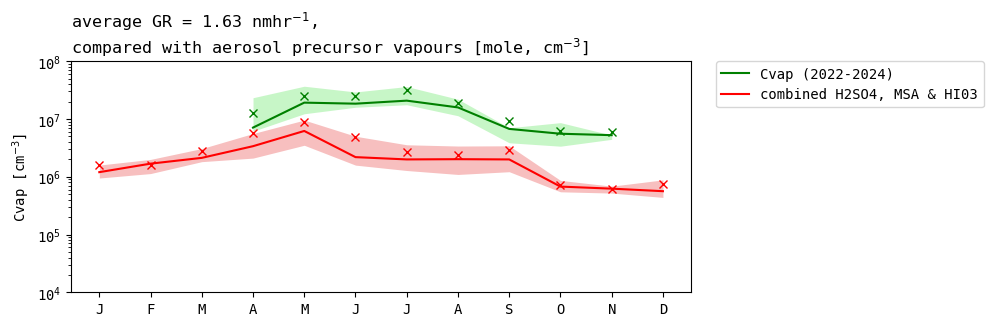

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.set_ylabel('Cvap [cm$^{-3}$]')
plot_months(df_Cv_M, color='green', lightcolor='lightgreen', label='Cvap (2022-2024)', ax=ax)
ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])

plot_months(df_v_M, label='combined H2SO4, MSA & HI03', ax=ax)
ax.set_ylim(10**4, 10**8)

ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)

average_GR = np.round(df_slope_hr.slope.mean(),2)
ax.set_title('average GR = '+str(average_GR)+' nmhr$^{-1}$,\ncompared with aerosol precursor vapours [mole, cm$^{-3}$]',
              loc='left')

plt.show()

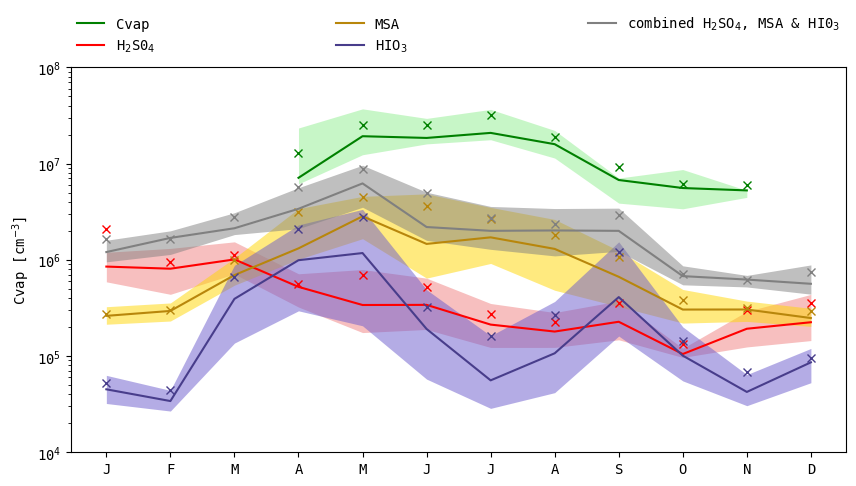

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_ylabel('Cvap [cm$^{-3}$]')
plot_months(df_Cv_M, color='green', lightcolor='lightgreen', label='Cvap', ax=ax)
ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])

#plot_months(df_v_M, label='combined H2SO4, MSA & HI03', ax=ax)
plot_months(df_vapours_H2S04_M, label='H$_{2}$S0$_{4}$', ax=ax)
plot_months(df_vapours_MSA_M, label='MSA', color='darkgoldenrod', lightcolor='gold', ax=ax)
plot_months(df_vapours_HIO3_M, label='HIO$_{3}$', 
            color='darkslateblue', lightcolor='slateblue',  ax=ax)
plot_months(df_v_M, label='combined H$_{2}$SO$_{4}$, MSA & HI0$_{3}$', color='gray', lightcolor='gray', ax=ax)

ax.set_ylim(10**4, 10**8)

ax.set_yscale('log')
ax.legend(frameon=False,
          bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand", borderaxespad=0, ncol=3)

average_GR = np.round(df_slope_hr.slope.mean(),2)
# ax.set_title('average GR = '+str(average_GR)+' nmhr$^{-1}$,\ncompared with aerosol precursor vapours [mole, cm$^{-3}$]',
#               loc='left')

plt.show()

In [ ]:
average_GR

1.63

In [ ]:
import scipy.io
beck_NyA = scipy.io.loadmat(current_dir+'\\Data\\beck_data\\Data_Figure1\\Figure1_Villum_NyAlesund.mat')

In [ ]:
beck_NyA.keys()

dict_keys(['__header__', '__version__', '__globals__', 'NYA_HOM', 'NYA_IA', 'NYA_MSA', 'NYA_SA', 'NYA_chlorophyll_phytoplankton', 'NYA_chlorophyll_phytoplankton_time', 'NYA_radiation', 'NYA_radiation_time', 'NYA_vapours_time', 'Villum_IA', 'Villum_IA_time', 'Villum_MSA', 'Villum_MSA_time', 'Villum_SA', 'Villum_SA_time', 'Villum_radiation', 'Villum_radiation_time'])

In [ ]:
beck_NyA_time = pd.DataFrame(np.reshape(beck_NyA['NYA_vapours_time'], (155,1)), columns=['NYA_vapours_time'])
beck_NyA_HOM = pd.DataFrame(beck_NyA['NYA_HOM'], columns=['NYA_HOM'])
beck_NyA_IA = pd.DataFrame(beck_NyA['NYA_IA'], columns=['NYA_IA'])
beck_NyA_MSA = pd.DataFrame(beck_NyA['NYA_MSA'], columns=['NYA_MSA'])
beck_NyA_SA = pd.DataFrame(beck_NyA['NYA_SA'], columns=['NYA_SA'])
df_beck = pd.concat([beck_NyA_time, beck_NyA_HOM, beck_NyA_IA, beck_NyA_MSA, beck_NyA_SA], axis=1)
df_beck = df_beck.dropna(how='all')

In [ ]:
df_beck

,NYA_vapours_time,NYA_HOM,NYA_IA,NYA_MSA,NYA_SA
0,736779,1.650109e+06,3.496475e+05,47785.961421,67243.798747
1,736780,1.416111e+06,1.114662e+06,60468.112001,62139.837904
2,736781,3.305865e+05,5.970127e+05,19381.156454,96931.842365
3,736782,7.607567e+05,6.322761e+05,58747.151870,137881.030644
4,736783,5.992598e+05,6.028245e+05,76275.241195,173417.524187
...,...,...,...,...,...
150,736929,1.513369e+07,2.583058e+06,250485.156023,446575.365741
151,736930,1.323886e+07,1.519896e+06,117424.677158,582939.294300
152,736931,1.953190e+06,6.486641e+05,354842.661403,314116.992342
153,736932,NaN,3.013716e+05,204926.060741,222334.733763


In [ ]:

start_date=pd.to_datetime('2017-03-28')
end_date=pd.to_datetime('2017-08-31')
offset=6 #get it right with plot
dates = pd.date_range(start_date-timedelta(days=offset), end_date-timedelta(days=2)-timedelta(days=offset),freq='d')
print(dates)
print(len(dates))

df_beck.loc[:,'dates'] = dates
df_beck = df_beck.set_index('dates')

DatetimeIndex(['2017-03-22', '2017-03-23', '2017-03-24', '2017-03-25',
               '2017-03-26', '2017-03-27', '2017-03-28', '2017-03-29',
               '2017-03-30', '2017-03-31',
               ...
               '2017-08-14', '2017-08-15', '2017-08-16', '2017-08-17',
               '2017-08-18', '2017-08-19', '2017-08-20', '2017-08-21',
               '2017-08-22', '2017-08-23'],
              dtype='datetime64[ns]', length=155, freq='D')
155


In [ ]:
df_beck['totalvapours'] = df_beck[['NYA_HOM', 'NYA_IA', 'NYA_MSA', 'NYA_SA']].sum(axis=1)

In [ ]:
df_beck['HOMS_total'] = df_beck['NYA_HOM']/df_beck['totalvapours']

In [ ]:
df_beck

,NYA_vapours_time,NYA_HOM,NYA_IA,NYA_MSA,NYA_SA,totalvapours,HOMS_total
dates,,,,,,,
2017-03-22,736779,1.650109e+06,3.496475e+05,47785.961421,67243.798747,2.114786e+06,0.780272
2017-03-23,736780,1.416111e+06,1.114662e+06,60468.112001,62139.837904,2.653381e+06,0.533701
2017-03-24,736781,3.305865e+05,5.970127e+05,19381.156454,96931.842365,1.043912e+06,0.316680
2017-03-25,736782,7.607567e+05,6.322761e+05,58747.151870,137881.030644,1.589661e+06,0.478565
2017-03-26,736783,5.992598e+05,6.028245e+05,76275.241195,173417.524187,1.451777e+06,0.412777
...,...,...,...,...,...,...,...
2017-08-19,736929,1.513369e+07,2.583058e+06,250485.156023,446575.365741,1.841381e+07,0.821866
2017-08-20,736930,1.323886e+07,1.519896e+06,117424.677158,582939.294300,1.545913e+07,0.856379
2017-08-21,736931,1.953190e+06,6.486641e+05,354842.661403,314116.992342,3.270813e+06,0.597157


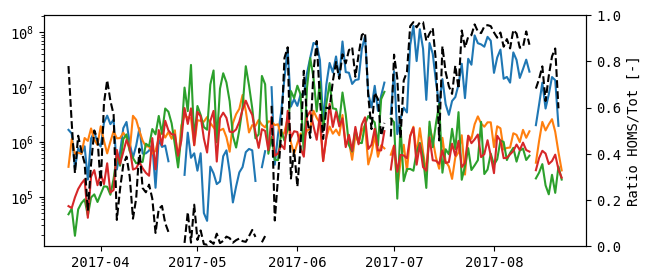

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
plt.plot(df_beck['NYA_HOM'].index, df_beck['NYA_HOM'].values, '-')
plt.plot(df_beck['NYA_IA'].index, df_beck['NYA_IA'].values, '-')
plt.plot(df_beck['NYA_MSA'].index, df_beck['NYA_MSA'].values, '-')
plt.plot(df_beck['NYA_SA'].index, df_beck['NYA_SA'].values, '-')
ax2 = ax.twinx()
ax2.plot(df_beck['NYA_SA'].index, df_beck['HOMS_total'].values, '--', c='k')
ax2.set_ylim(0,1)
ax2.set_ylabel('Ratio HOMS/Tot [-]')
ax.set_yscale('log')
#Ny-Ålesund from April 12 to May 26, 2017. March 2017 until the end of August 2017
plt.show()

In [ ]:
df_beck['DOY'] = df_beck.index.dayofyear

In [ ]:
df_beck

,NYA_vapours_time,NYA_HOM,NYA_IA,NYA_MSA,NYA_SA,totalvapours,HOMS_total,DOY
dates,,,,,,,,
2017-03-22,736779,1.650109e+06,3.496475e+05,47785.961421,67243.798747,2.114786e+06,0.780272,81
2017-03-23,736780,1.416111e+06,1.114662e+06,60468.112001,62139.837904,2.653381e+06,0.533701,82
2017-03-24,736781,3.305865e+05,5.970127e+05,19381.156454,96931.842365,1.043912e+06,0.316680,83
2017-03-25,736782,7.607567e+05,6.322761e+05,58747.151870,137881.030644,1.589661e+06,0.478565,84
2017-03-26,736783,5.992598e+05,6.028245e+05,76275.241195,173417.524187,1.451777e+06,0.412777,85
...,...,...,...,...,...,...,...,...
2017-08-19,736929,1.513369e+07,2.583058e+06,250485.156023,446575.365741,1.841381e+07,0.821866,231
2017-08-20,736930,1.323886e+07,1.519896e+06,117424.677158,582939.294300,1.545913e+07,0.856379,232
2017-08-21,736931,1.953190e+06,6.486641e+05,354842.661403,314116.992342,3.270813e+06,0.597157,233


0.005300481360885913
dates
2017-03-22    0.127286
2017-03-23    0.132587
2017-03-24    0.137887
2017-03-25    0.143188
2017-03-26    0.148488
                ...   
2017-08-17    0.911758
2017-08-18    0.917058
2017-08-19    0.922359
2017-08-20    0.927659
2017-08-21    0.932960
Name: DOY, Length: 146, dtype: float64


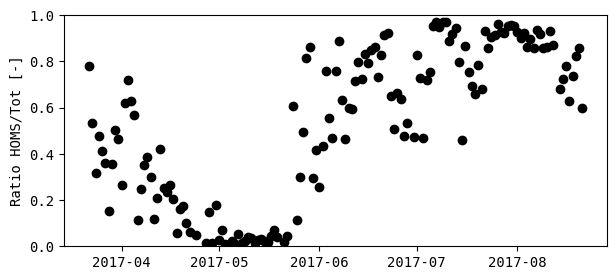

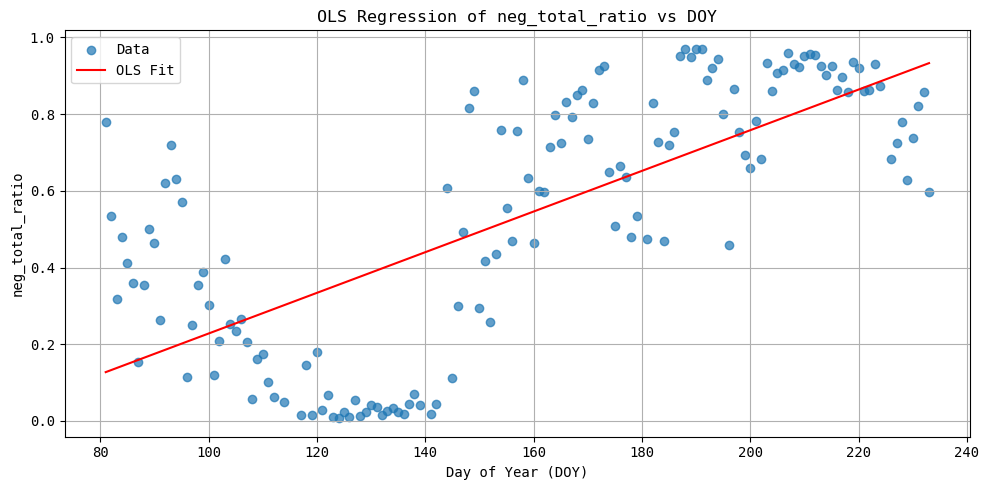

In [ ]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(7, 3))

df = df_beck.copy()

df = df[['DOY', 'HOMS_total']].copy()
df = df.dropna(how='any')

# Extract X and Y
x = df['DOY']
y = df['HOMS_total']

# Perform linear regression (OLS)
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(slope)
# Generate predicted y values
y_fit = slope * x + intercept
print(y_fit)
# Plot
plt.figure(figsize=(10, 5))
plt.scatter(x, y, label='Data', alpha=0.7)
plt.plot(x, y_fit, color='red', label='OLS Fit')
plt.xlabel('Day of Year (DOY)')
plt.ylabel('neg_total_ratio')
plt.title('OLS Regression of neg_total_ratio vs DOY')
plt.legend()
plt.grid(True)
plt.tight_layout()

ax.plot(df_beck['NYA_SA'].index, df_beck['HOMS_total'].values, 'o', c='k')
ax.set_ylim(0,1)
ax.set_ylabel('Ratio HOMS/Tot [-]')
#Ny-Ålesund from April 12 to May 26, 2017. March 2017 until the end of August 2017
plt.show()

In [ ]:
df[df.index < '2017-06-01']['HOMS_total'].mean()

0.23914115168283182

In [ ]:
df_beck.head(2)

,NYA_vapours_time,NYA_HOM,NYA_IA,NYA_MSA,NYA_SA,totalvapours,HOMS_total,DOY
dates,,,,,,,,
2017-03-22,736779,1.650109e+06,3.496475e+05,47785.961421,67243.798747,2.114786e+06,0.780272,81
2017-03-23,736780,1.416111e+06,1.114662e+06,60468.112001,62139.837904,2.653381e+06,0.533701,82


In [ ]:
df_beck['total'] = df_beck['NYA_HOM']+df_beck['NYA_IA']+df_beck['NYA_MSA']+df_beck['NYA_SA']

In [ ]:
df_beck['month'] = df_beck.index.month
df_beck_HOM_M = monthly_averages(df_beck, var='NYA_HOM')
df_beck_IA_M = monthly_averages(df_beck, var='NYA_IA')
df_beck_MSA_M = monthly_averages(df_beck, var='NYA_MSA')
df_beck_SA_M = monthly_averages(df_beck, var='NYA_SA')
df_beck_T_M = monthly_averages(df_beck, var='total')

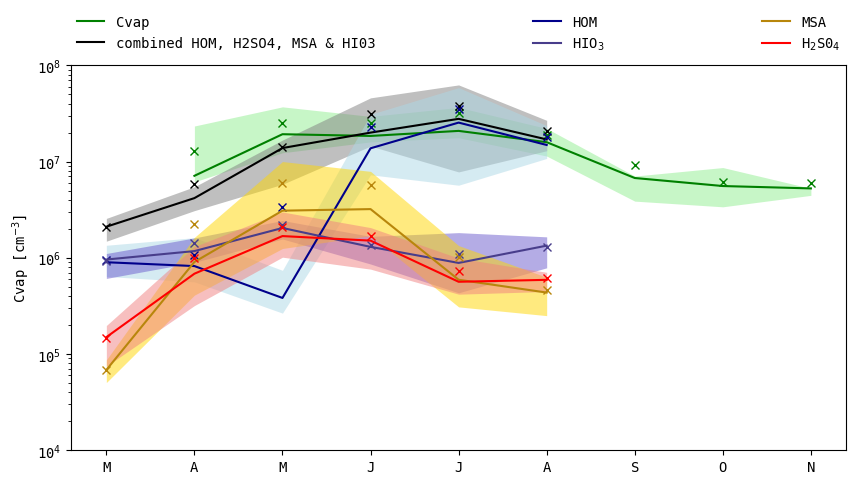

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_ylabel('Cvap [cm$^{-3}$]')
plot_months(df_Cv_M, color='green', lightcolor='lightgreen', label='Cvap', ax=ax)
ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])

# #plot_months(df_v_M, label='combined H2SO4, MSA & HI03', ax=ax)
# plot_months(df_vapours_H2S04_M, label='H$_{2}$S0$_{4}$', ax=ax)
# plot_months(df_vapours_MSA_M, label='MSA', color='darkgoldenrod', lightcolor='gold', ax=ax)
# plot_months(df_vapours_HIO3_M, label='HIO$_{3}$', 
#             color='darkslateblue', lightcolor='slateblue',  ax=ax)
# plot_months(df_v_M, label='combined H$_{2}$SO$_{4}$, MSA & HI0$_{3}$', color='gray', lightcolor='gray', ax=ax)

ax.set_ylim(10**4, 10**8)

average_GR = np.round(df_slope_hr.slope.mean(),2)
# ax.set_title('average GR = '+str(average_GR)+' nmhr$^{-1}$,\ncompared with aerosol precursor vapours [mole, cm$^{-3}$]',
#               loc='left')

plot_months(df_beck_T_M, color='k', lightcolor='gray', 
            label='combined HOM, H2SO4, MSA & HI03', ax=ax)
plot_months(df_beck_HOM_M, label='HOM', color='darkblue', lightcolor='lightblue', ax=ax)
plot_months(df_beck_IA_M, color='darkslateblue', lightcolor='slateblue', label='HIO$_{3}$', ax=ax)
plot_months(df_beck_MSA_M, color='darkgoldenrod', lightcolor='gold', label='MSA',ax=ax)
plot_months(df_beck_SA_M, label='H$_{2}$S0$_{4}$', ax=ax)

ax.set_yscale('log')
ax.legend(frameon=False,
          bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand", borderaxespad=0, ncol=3)

plt.show()

In [ ]:
df_beck_HOM_M[3:] #['mean'] #.mean()/10**6

,q50,q25,q75,mean
month,,,,
6,1.372161e+07,7.280264e+06,3.092555e+07,2.267384e+07
7,2.537949e+07,5.672439e+06,5.858708e+07,3.503278e+07
8,1.486090e+07,1.076533e+07,2.359998e+07,1.807376e+07
